In [1]:
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
g = 0.2       # quartic coefficient
m = 1       # mass
w = 1       # supposed to be omega i.e. frequency of harmonic oscillator
hb = 1      # short for hbar

b = 10.0    # integral upper bound for Gauss-Legendre quadrature
a = -10.0   # integral lower bound for Gauss-Legendre quadrature (G-L Q)

c1 = (b-a)/2    # these two helper variables are convenient to calculate change of interval for G-L Q
c2 = (b+a)/2

samples, weights = np.polynomial.legendre.leggauss(99)      # G-L Q sample points & weights


In [ ]:
#the wavefunction that solves the unperturbed hamiltonian
def wavefunction(n, x, Omega):
    freq = np.sqrt(w**2 + Omega**2)
    xi = x * np.sqrt(m*freq/hb)
    return np.exp(-(xi**2)/2) * (m*freq /(np.pi*hb))**(1/4) * ((2**n)*sp.special.factorial(n))**(-1/2) * sp.special.eval_hermite(n, xi)

#perturbation to the hamiltonian
def H1(x, Omega):
    return g*(x**4) - (1.0/2)*m*(Omega**2)*(x**2)

#helper function to determine the integrand for calculating the expectation value
def trans_amp(n1, n2, x, Omega):
    return wavefunction(n1, x, Omega) * H1(x, Omega) * wavefunction(n2, x, Omega)

#zeroth order energy, i.e. energy of the unperturbed Hamiltonian
def E0(n, Omega):
    return (n*1.0 + 1.0/2)*hb*np.sqrt(w**2 + Omega**2)

#first order energy correction
def E1(n, Omega):
    return c1 * np.dot(weights, trans_amp(n, n, c1*samples + c2, Omega))

#second order energy correction
def E2(n, Omega):
    E_2 = 0
    # with some more analysis you can show that you can skip every other term, but we'll keep it general
    for i in range(0, n + 5):
        if (i == n):
            continue 

        transition_amplitude = c1 * np.dot(weights, trans_amp(n, i, c1*samples + c2, Omega))
        E_2 += transition_amplitude**2 / (E0(n, Omega) - E0(i, Omega))

    return E_2

# first order total energy
def ground1(Omega):
    return E0(0, Omega) + E1(0, Omega)

# second order total energy
def ground2(Omega):
    return E0(0, Omega) + E1(0, Omega)  + E2(0, Omega)


# basic naive way to find the VPT first order energy. Works here.
def vpt_energy_fo(guess):
    return sp.optimize.minimize(ground1, x0 = [guess])

# basic navie way to find the VPT second order energy. Does not work here. We will end up needing the derivative functions.
def vpt_energy_so(guess):
    return sp.optimize.minimize(ground2, x0 = [guess])

def first_derivative_so(Omega):
    h=1e-5
    return (ground2(Omega + h) - ground2(Omega - h)) / (2*h)

def second_derivative_so(Omega):
    h=1e-5
    return (ground2(Omega + h) - 2*ground2(Omega) + ground2(Omega - h)) / h**2



I was previously finding zeroes of a function using a grid search method, and then using the root scalar function of SciPy, but I figured it's better and more intuitive to just follow the suggestion of minimizing the first derivative. And so this is what I've done below. 

The results are the expected ones so that's good.

In [105]:
sol = sp.optimize.minimize(ground1, x0=[1.0])

print(sol.x)
print(ground1(sol.x[0]))

[0.93600184]
0.6049007479976076


In [4]:
sol = sp.optimize.minimize(first_derivative_so, x0=[1.0])

print(sol.x)
print(ground2(sol.x[0]))

[1.07056675]
0.6024386591749555


Here I'm going to go ahead and get started on the heatmaps for the Hamiltonian. Now that we have Omega we can retroactively plug it back into every function to get the perturbation to the Hamiltonian, and the wavefunctions. In this case the integrand I need is captured by trans_amp already, so I just integrate that. We can also save some time by noting that the matrix form of $\hat{H}_1$ is going to be symmetric, so it goes from $n^2$ to $\binom{n}{2}$ integrals to calculate which is somewhat less. 

In [106]:
solution = sol.x[0]
size = 13
energy_matrix1 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, 0))

        energy_matrix1[i][j] = integral
        energy_matrix1[j][i] = integral


In [107]:
energy_matrix2 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, 0.936))

        energy_matrix2[i][j] = integral
        energy_matrix2[j][i] = integral


In [108]:
energy_matrix3 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, 1.0706))

        energy_matrix3[i][j] = integral
        energy_matrix3[j][i] = integral


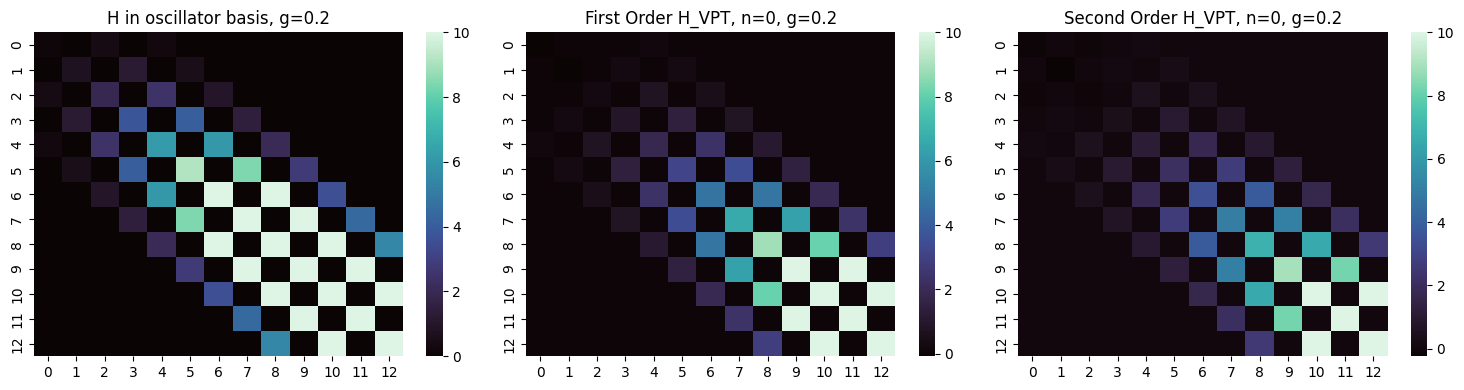

In [109]:
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)
ax1.set_title('H in oscillator basis, g=0.2')
ax2.set_title('First Order H_VPT, n=0, g=0.2')
ax3.set_title('Second Order H_VPT, n=0, g=0.2')
sns.heatmap(energy_matrix1, ax=ax1, vmax = 10, cmap='mako')
sns.heatmap(energy_matrix2, ax=ax2, vmax = 10, cmap ='mako')
sns.heatmap(energy_matrix3, ax=ax3, vmax = 10, cmap = 'mako')

fig.tight_layout()
plt.show()


As I've mentioned in the comments above already the basic easy VPT application gives the right result for first order (directly below) but the wrong result for the second order (the one below the first order calc). 

Also, the stuff below here is back when I was performing a grid search to find the zeroes and stuff, and I've now moved onto an optimizer which is above. I'll probably end up exporting the code below to another file anyway. 

In [ ]:
# find the k-th order derivative of v1 w.r.t. v2, where v1 and v2 are vectors. 
# Note that this function uses recursion. which will fail if k < 0 resulting in an infinite loop.
def v_derivative(v1, v2, k):
    if(k == 0):                 # base case
        return v1
    
    vd = np.zeros_like(v1, dtype=np.float64)

    for i in range(1, len(vd) - 1):
        if(v2[i+1] - v2[i-1] != 0):
            vd[i] = (v1[i+1] - v1[i-1])/(v2[i+1] - v2[i-1])     # classic central difference formula

    return v_derivative(vd, v2, k-1)        # recursive call

#find the zeroes of the k-th order derivative of yvec w.r.t. xvec, where the derivative points are rounded to precision decimals.
def deriv_zeroes(xvec, yvec, k, precision):
    vector = v_derivative(yvec, xvec, k)
    rounded_vec = np.round(vector, decimals=precision)
    zero_points = np.where(rounded_vec == 0)[0][1:-1]           # derivative endpointsa are defined as zero, just remove them

    return zero_points

In [324]:
print(vpt_energy_fo(1.0))

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.6049007479976076
        x: [ 9.360e-01]
      nit: 4
      jac: [ 1.490e-08]
 hess_inv: [[ 4.761e+00]]
     nfev: 10
     njev: 5


In [281]:
print(vpt_energy_so(1.0))

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.5449999999999999
        x: [-1.539e-08]
      nit: 3
      jac: [ 7.451e-09]
 hess_inv: [[ 1.905e+00]]
     nfev: 24
     njev: 12


Now we do the less naive way, using the derivatives and finding their zeroes when available. I'm being a bit sloppy with naming but xaxis is supposed to be a list of $\Omega$ values and yaxis is supposed to be the corresponding energies. I don't want to break the code now messing with the names, so we're going to stick with it.

For the first order calc we could have just done the straight VPT calculation without bothering with the helper functions but I think it's better to generalize using them anyway so here goes. Firstly I set it up using the function "ground1" and not "ground2", since ground1 is to find the ground state energy to the first perturbative order. Nothing special in just setting up the x and y vectors. Next, we figure out where all the zeroes are for the first derivative. Recall we want this to be zero somewhere. Luckily for first order, the first derivative already contains such a zero, as you can see below. 

For the precision parameter, I just kept increasing it until I stopped seeing a bunch of duplicates in and around the actual points. Finally we can just plug in the zeroes we see back into the energy functions that have $\Omega$ as a parameter to get the energy we're looking for. This is in the last code blurb before the second order stuff begins.

As you can see in the output of this block, the predicted energy is ~0.6049. Interestingly this is actually exactly what you get if you perform a variational calculation using the Gaussian as a guess. You can see this in the corresponding Jupyter notebook in this file system.

In [305]:
xaxis = np.arange(-2, 2, 0.0001)
yaxis = np.array([ground1(xaxis[i]) for i in range(len(xaxis))])

In [309]:
pts = np.round(deriv_zeroes(xaxis, yaxis, 1, 5), decimals = 3)
zero_xpts = xaxis[pts]

print(zero_xpts)

[-9.36000000e-01 -2.20268248e-13  9.36000000e-01]


In [310]:
print(ground1(0.936))

0.6049007479979343


Now we begin doing the second order stuff where it becomes slightly less trivial. This time we can play around with the precision and note that unless we bring it down to like 2 decimal places, there are no zeroes anywhere in the first derivative. It's not sensible to accept those zeroes, I would think, since our precision in the construction of $\Omega$ values is in the order of ten-thousandths. So I conclude that there are no zeroes in the first derivative. You can actually see this directly on a graph, or if you further increase the precision of the $\Omega$ values, but I won't demonstrate that since it's kind of ugly and pretty easy to do anyway. 

To look for minimum sensitivity the next step is to try to find zeroes of the next derivative order, so we move onto the second derivative. This time we see that there are actually non-trivial answers, and further even playing around with the precision there's a couple duplicates to parse out. This is part of what makes writing a generalized function a little difficult for me, since these kinds of caveats can't really be predicted, at least to my knowledge, and it's just easier for me to look at it and discern that there's duplicates.

It's worth noting there are two nontrivial answers: $\Omega \approx 1.0706,  0.3335$. To figure out which one to use, I also evaluate the first order derivative there. The point with the smaller lower order derivative wins the low sensitivity contest and is elected as the winner, and then as usual we just plug it back into the energy function to find the second order corrected energy. Whether you use 1.0706 or 1.0707 is sort of irrelevant since you realistically shouldn't be rounding it farther than the third decimal, in which case both give the same answer of $E^{(2)} \approx 0.6024$. Again there's an interesting parallel in that this gives roughly the same answer as the variational method if we picked a guess wavefunction of an extended Gaussian, i.e. a Gaussian but the $x^2$ term in the exponent is added on to an $x^4$ term too. 

This last part also plays a role in my inability to write a completely automatic function for this entire process, since it requires retroactively going back to the lower order derivatives and seeing which ones corresponding to the zeroes of higher order derivatives, are the most sensitive. Of course there's a way to do it, but it's not entirely clear to me that, in all situations, a clear less sensitive option will appear or how to gauge sensitivity  when the order of derivative we're looking at is like 4 or 5, and details on sensitivity then depend on the 3-4 lower derivatives. So I've elected to keep this part manual for now.

In [8]:
xaxis = np.arange(-2, 2, 0.0001)
yaxis = np.array([ground2(xaxis[i]) for i in range(len(xaxis))])

In [315]:
pts = np.round(deriv_zeroes(xaxis, yaxis, 1, 4), decimals = 3)
zero_xpts = xaxis[pts]

print(zero_xpts)

[-2.20268248e-13]


In [318]:
pts = np.round(deriv_zeroes(xaxis, yaxis, 2, 4), decimals = 3)
zero_xpts = xaxis[pts]

print(zero_xpts)
print(v_derivative(yaxis, xaxis, 1)[pts])

[-1.0707 -1.0706 -0.3335  0.3335  1.0706  1.0707]
[-0.00341346 -0.00341346 -0.10542122  0.10542122  0.00341346  0.00341346]


In [323]:
print(ground2(1.0706))

0.6024387726603617


Stuff below is just testing stuff, not serious. But there's some nice illustrations on what the functions and derivatives look like if you can decipher what I've written. 

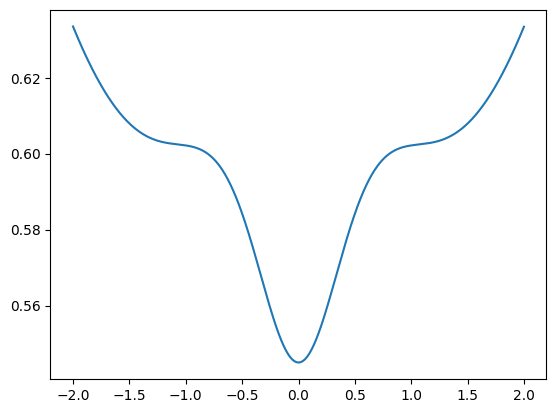

In [220]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(xaxis, yaxis)

In [13]:
deriv =  v_derivative(yaxis, xaxis, 1)
dderiv = v_derivative(deriv, xaxis, 1)

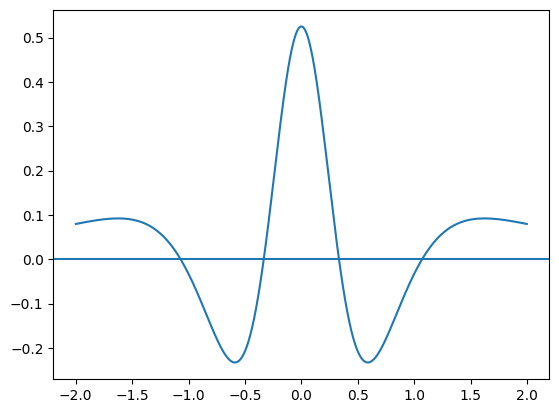

In [14]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(xaxis[10:-10], dderiv[10:-10])
#ax.plot(xaxis[10:-10], deriv[10:-10])
ax.axhline(0)
